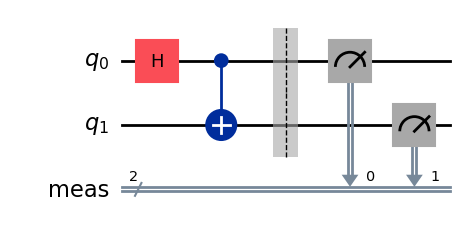

In [1]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

qc.draw(output="mpl")

In [2]:
from qiskit.primitives import StatevectorSampler

result = StatevectorSampler().run([qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
counts

{'11': 510, '00': 514}

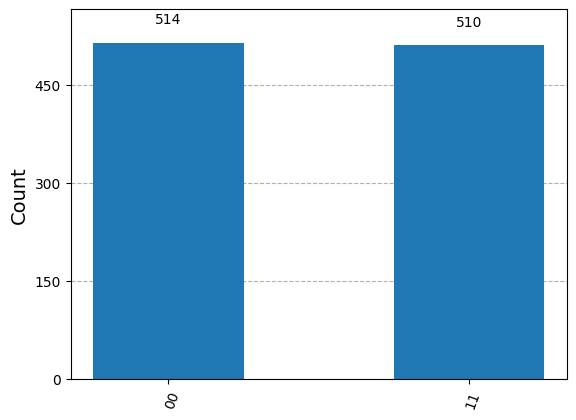

In [3]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

In [7]:
from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend = FakeManilaV2()
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_qc = pm.run(qc)

result = SamplerV2(mode=backend).run([isa_qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
counts

/home/andre/anaconda3/envs/quantum/lib/python3.8/site-packages/jwt/utils.py:7: CryptographyDeprecationWarning: Python 3.8 is no longer supported by the Python core team and support for it is deprecated in cryptography. The next release of cryptography will remove support for Python 3.8.
  from cryptography.hazmat.primitives.asymmetric.ec import EllipticCurve


{'11': 484, '00': 463, '10': 49, '01': 28}

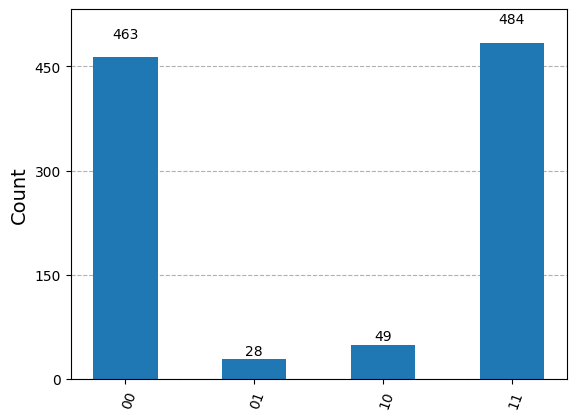

In [8]:
plot_histogram(counts)

In [9]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    token="1cWhATaePVqHTZOvmUZK4trxDID_8EEJnQgV442SeLly",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/870dd10d1dd1443d8e1767c831dfe739:061301f3-78d0-4e1f-8ac6-7a92a0ca4066::",
    overwrite=True
)

In [10]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
print(f"Running on {backend.name}")

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_qc = pm.run(qc)

result = SamplerV2(mode=backend).run([isa_qc], shots=1024).result()
counts = result[0].data.meas.get_counts()
counts

Running on ibm_fez


{'11': 455, '00': 519, '10': 23, '01': 27}

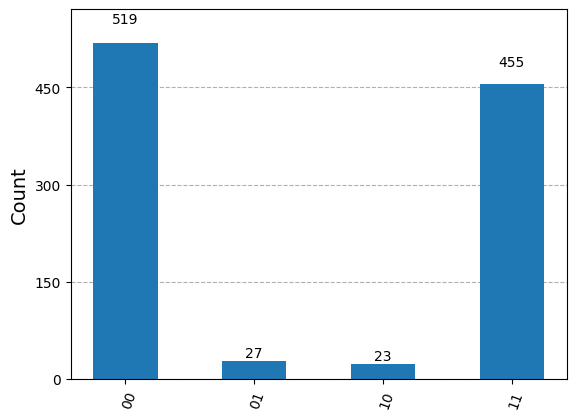

In [11]:
plot_histogram(counts)